# Annotating Gene Sets with Biological Processes Using an LLM

This notebook contains a pipeline to benchmark AnnDictionary's biological process annotation functions using gene sets of known function from GOBP.

In [ ]:
import os
os.chdir("/path/to/benchmark_llms/benchmark_pipeline")
# os.getcwd()

In [ ]:
"""
Full evaluation pipeline
------------------------
• Generates LLM-based GO-BP annotations for sampled gene sets  
• Embeds all texts (GO labels + LLM labels)  
• Computes “Close Match” flags (cosine similarity ≥95th-percentile vs all GO labels)  
• Builds scatter & bar plots (black edge = close match, red = not close match)  
• Persists underlying data (plots_data/*.pkl) incl. GO embeddings

Notes
-----
This notebook is intended to be run from the `benchmark_llms/benchmark_pipeline` directory.

If running from the benchmark_llms conda environment, this notebook requires the additional packages:
- gseapy
Which can be installed with:
pip install gseapy
"""

import os
import time
import re
import random

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp
import anndict as adt
import openai
import pandas as pd
import sigfig

from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings("ignore")

import sys

from dotenv import load_dotenv


load_dotenv()
source_dir = os.environ["SOURCE_DIR"]           # path to benchmark_llms/src
sys.path.append(source_dir)

from src import PROVIDERS, ENDPOINTS, MODEL_TICK_LABELS, replace_tick_labels

In [ ]:
# Set openai api key

openai.api_key = os.getenv("OPENAI_API_KEY")
# benchmarking parameters
random.seed(42)
n_runs = 5

# Gene set sampling (GO‑BP pathways, 3‑100 genes)
gobp             = gp.get_library(name="GO_Biological_Process_2023", organism="Human")
gene_sets_3_100  = {t: g for t, g in gobp.items() if 3 <= len(g) <= 100}
sampled_terms    = random.sample(list(gene_sets_3_100.keys()), 500)
gene_sets        = {t: gene_sets_3_100[t] for t in sampled_terms}

acc_pat = re.compile(r"\s*\(GO:\d+\)$")
df = pd.DataFrame(
    {
        "GOBP_label": list(gene_sets.keys()),
        "GOBP_label_no_acc": [acc_pat.sub("", t) for t in gene_sets],
        "gene_list": list(gene_sets.values()),
    }
)

In [ ]:
#Run annotations
def _annotate(gene_list):
    return adt.ai_biological_process(gene_list=gene_list)

# Iterate over all providers and endpoints -----------------------------
for provider, models in ENDPOINTS.endpoints.items():
    if provider not in PROVIDERS:
        raise ValueError(f"Provider '{provider}' missing in PROVIDERS")

    base_cfg = PROVIDERS[provider].copy()

    for model in models:
        llm_cfg          = base_cfg.copy()
        llm_cfg["model"] = model               # ensure model is set

        adt.configure_llm_backend(**llm_cfg)    # configure backend for this provider/model
        col_prefix = f"{model}"
        for run in range(1, n_runs + 1):
            col = f"{col_prefix}_run_{run}"

            if col in df.columns:
                print(f"Column {col} already exists, skipping...")
                # skip if column already exists (to handle rerunning after api errors)
                continue

            with ThreadPoolExecutor(max_workers=10) as ex:
                df[col] = list(ex.map(_annotate, df["gene_list"]))
        #sleep just over 1 min in between models
        # time.sleep(70)


# Get text embeddings for all unique labels
label_cols     = [c for c in df.columns if re.search(r"_run_\d+$", c)]
unique_texts   = set(df["GOBP_label_no_acc"])
for c in label_cols:
    unique_texts.update(df[c])
unique_texts   = sorted(unique_texts)

embeddings = {}
batch = []
for txt in unique_texts:
    batch.append(txt)
    if len(batch) == 2048 or txt == unique_texts[-1]:
        resp = openai.embeddings.create(model="text-embedding-3-large", input=batch)
        for t, e in zip(batch, resp.data):
            embeddings[t] = np.array(e.embedding, dtype=np.float32)
        batch = []

# Get text embeddings for all GO-BP terms
all_go_terms   = sorted({acc_pat.sub("", t) for t in gobp})
missing_terms  = [t for t in all_go_terms if t not in embeddings]
for i in range(0, len(missing_terms), 2048):
    batch = missing_terms[i : i + 2048]
    resp  = openai.embeddings.create(model="text-embedding-3-large", input=batch)
    for t, e in zip(batch, resp.data):
        embeddings[t] = np.array(e.embedding, dtype=np.float32)

all_go_embs = np.vstack([embeddings[t] for t in all_go_terms])

# Get 95-percentile similarity threshold per LLM label
unique_llm_labels = {lbl for c in label_cols for lbl in df[c]}
label_thresh_95 = {}
for lbl in unique_llm_labels:
    sims = cosine_similarity(embeddings[lbl].reshape(1, -1), all_go_embs)[0]
    label_thresh_95[lbl] = np.percentile(sims, 95)

scatter_rows, bar_rows, run_performance = [], [], {}

for col in label_cols:
    model   = col.split("_run_")[0]
    run_num = int(col.split("_run_")[1])

    flags, sims, pcts = [], [], []
    for go_txt, lbl in zip(df["GOBP_label_no_acc"], df[col]):
        vec_lbl   = embeddings[lbl].reshape(1, -1)
        sim_tgt   = cosine_similarity(vec_lbl, embeddings[go_txt].reshape(1, -1))[0, 0]
        sims_all  = cosine_similarity(vec_lbl, all_go_embs)[0]
        pct       = (np.sum(sims_all <= sim_tgt) / len(sims_all)) * 100
        close_flag = int(sim_tgt >= label_thresh_95[lbl])

        flags.append(close_flag)
        sims.append(sim_tgt)
        pcts.append(pct)

        scatter_rows.append(
            dict(
                model=model,
                run=run_num,
                term=go_txt,
                label=lbl,
                similarity=sim_tgt,
                percentile=pct,
                close_match=close_flag,
            )
        )

    df[f"{col}_close"]       = flags
    df[f"{col}_percentile"] = pcts

    run_perf = np.mean(flags)
    run_performance[col] = run_perf
    bar_rows.append(dict(model=model, run=run_num, close_match_rate=run_perf))

scatter_df = pd.DataFrame(scatter_rows)
bar_df     = pd.DataFrame(bar_rows)

Column meta.llama3-1-8b-instruct-v1:0_run_1 already exists, skipping...
Column meta.llama3-1-8b-instruct-v1:0_run_2 already exists, skipping...
Column meta.llama3-1-8b-instruct-v1:0_run_3 already exists, skipping...
Column meta.llama3-1-8b-instruct-v1:0_run_4 already exists, skipping...
Column meta.llama3-1-8b-instruct-v1:0_run_5 already exists, skipping...
Column meta.llama3-1-70b-instruct-v1:0_run_1 already exists, skipping...
Column meta.llama3-1-70b-instruct-v1:0_run_2 already exists, skipping...
Column meta.llama3-1-70b-instruct-v1:0_run_3 already exists, skipping...
Column meta.llama3-1-70b-instruct-v1:0_run_4 already exists, skipping...
Column meta.llama3-1-70b-instruct-v1:0_run_5 already exists, skipping...
Column meta.llama3-1-405b-instruct-v1:0_run_1 already exists, skipping...
Column meta.llama3-1-405b-instruct-v1:0_run_2 already exists, skipping...
Column meta.llama3-1-405b-instruct-v1:0_run_3 already exists, skipping...
Column meta.llama3-1-405b-instruct-v1:0_run_4 already

In [15]:
# Number of GOBP terms
print(f"Total Number of GOBP terms: {len(all_go_terms)}")

# Number of GOBP terms with between 3 and 100 genes
print(f"Number of GOBP terms with between 3 and 100 genes: {len(gene_sets_3_100)}")

Total Number of GOBP terms: 5406
Number of GOBP terms with between 3 and 100 genes: 5094


In [18]:
# Make results directory and save files
Path("res/17_figure_s4_and_table_1").mkdir(exist_ok=True)

scatter_df.to_pickle("res/17_figure_s4_and_table_1/figure_s4_data.pkl")
bar_df.to_pickle("res/17_figure_s4_and_table_1/biological_process_table_1_data.pkl")
df.to_pickle("res/17_figure_s4_and_table_1/match_table.pkl")

go_embeddings = {t: embeddings[t] for t in all_go_terms}
pd.to_pickle(go_embeddings, "res/17_figure_s4_and_table_1/go_embeddings.pkl")

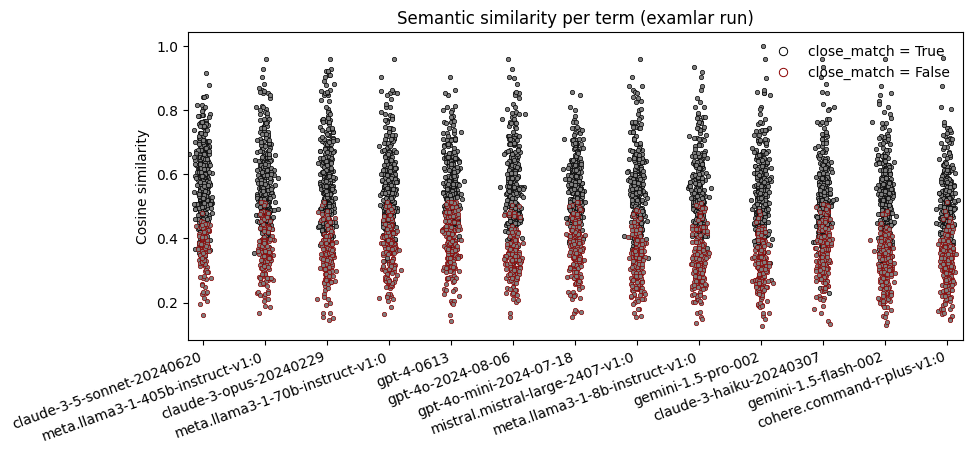

In [ ]:
# Make scatter plot of cosine similarity between LLM labels of gene sets and the gene set's GO-BP name
model_means   = scatter_df.groupby("model")["similarity"].mean()
unique_models = model_means.sort_values(ascending=False).index.tolist()
colours       = plt.get_cmap("Paired")(np.linspace(0, 1, len(unique_models)))
palette       = dict(zip(unique_models, colours))

fig1, ax1 = plt.subplots(figsize=(10, 4))

runs_per_model = 1
gap            = 1               # empty slot between model blocks (for clarity)

for m_idx, model in enumerate(unique_models):
    group_start = m_idx * (runs_per_model + gap)            # leftmost x of the block

    for run in range(1, runs_per_model + 1):
        sub = scatter_df[(scatter_df["model"] == model) &
                         (scatter_df["run"]   == run)].sample(frac=1, ignore_index=True)

        # x‑coordinate for this run (jittered for point overlap)
        x_center = group_start + (run - 1)
        xvals    = np.full(len(sub), x_center) + np.random.randn(len(sub)) * 0.12

        for cond, edge in ((True,  "black"),
                           (False, "darkred")):
            mask = sub["close_match"] == cond
            if mask.any():
                ax1.scatter(
                    xvals[mask],
                    sub.loc[mask, "similarity"],
                    # facecolor=palette[model],
                    facecolor="grey",
                    edgecolors=edge,
                    linewidths=0.5,
                    alpha=1,
                    s=10,
                )

# tick in the middle of each model block
tick_centres = [idx * (runs_per_model + gap) + (runs_per_model - 1) / 2
                for idx in range(len(unique_models))]
ax1.set_xticks(tick_centres)
ax1.set_xticklabels(unique_models, rotation=20, ha="right")

# x‑limits with padding
left_pad  = -0.5
right_pad = len(unique_models) * (runs_per_model + gap) - gap - 0.5
ax1.set_xlim(left_pad, right_pad)

ax1.set_ylabel("Cosine similarity")
ax1.set_title("Semantic similarity per term (examlar run)")

# legend for match / no‑match
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='w',
           markeredgecolor='black', markeredgewidth=0.7, markersize=6,
           label='close_match = True'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='w',
           markeredgecolor='darkred', markeredgewidth=0.7, markersize=6,
           label='close_match = False')
]
ax1.legend(handles=legend_elems, loc='upper right', frameon=False)


In [ ]:
#make table from bar_df
def format_with_sd(mean, sd, make_percent=False):
    """Format mean and standard deviation as 'mean (sd)' with appropriate rounding."""
    if make_percent:
        mean = mean * 100
        sd = sd * 100

    # Round mean to same decimal place as sd
    mean_rounded = sigfig.round(mean, uncertainty=sd, format='PDG')

    return mean_rounded


mean_table = (
    bar_df.groupby('model', sort=False)['close_match_rate']
      .mean()
      .to_frame('Close Match (% of Terms)')
)

std_table = (
    bar_df.groupby('model', sort=False)['close_match_rate']
      .std()
      .to_frame('Close Match (% of Terms)')
)

aggregated_table = pd.DataFrame(index=mean_table.index)
col = 'Close Match (% of Terms)'

aggregated_table[col] = [
    format_with_sd(mean_table.loc[idx, col], std_table.loc[idx, col], make_percent=True)
    for idx in mean_table.index
]

aggregated_table.reset_index(inplace=True)

html_table = aggregated_table.to_html(
    index=False,
    header=False,
    classes="sortable performance-table",
    border=0,
    escape=False,
)

html_table = html_table.split("<tbody>")[1].split("</tbody>")[0]

html_content = f"""
<table class="sortable performance-table" id="leaderboard">
  <thead>
    <tr>
      <th data-column="0" data-numeric="false"></th>
      <th data-column="1" data-numeric="true">Close Match (% of Terms)</th>
    </tr>
  </thead>
  <tbody>
    {html_table}
  </tbody>
</table>
"""

with open("res/17_figure_s4_and_table_1/biological_process_benchmark_table.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("Aggregated table saved to HTML file.")


Aggregated table saved to HTML file.


In [21]:
aggregated_table

,model,Close Match (% of Terms)
0,meta.llama3-1-8b-instruct-v1:0,61.7 ± 0.7
1,meta.llama3-1-70b-instruct-v1:0,70.8 ± 0.5
2,meta.llama3-1-405b-instruct-v1:0,71.9 ± 0.5
3,cohere.command-r-plus-v1:0,58.5 ± 0.7
4,mistral.mistral-large-2407-v1:0,62.76 ± 0.17
5,gemini-1.5-pro-002,66.32 ± 0.11
6,gemini-1.5-flash-002,60.52 ± 0.18
7,gpt-4-0613,65.24 ± 0.33
8,gpt-4o-2024-08-06,67.04 ± 0.33
9,gpt-4o-mini-2024-07-18,64.8 ± 0.5


In [22]:
fig1.savefig('res/17_figure_s4_and_table_1/figure_s4_similarity_scores_withlegend.svg', format='svg')

In [23]:
# Function to customize the scatterplot (taken from src/format_fig)
def customize_scatterplot(
    fig_tuple,
    remove_legend=False,
    x_tick_substrings=None,
    new_ylabel=None,
    new_xlabel=None,
    fig_size=3.5,
    fig_width=None,
    fig_height=None,
    preserve_sizes=True,
    new_tick_labels=None,
):
    """
    Customize a scatterplot figure with various formatting options.

    Parameters
    ----------
    fig_tuple : tuple
        A tuple containing the figure and axes objects to customize.

    remove_legend : bool, optional
        Whether to remove the legend. Default is False.

    x_tick_substrings : list of str, optional
        A list of substrings to remove from x-axis tick labels. Default is None.

    new_ylabel : str, optional
        The new y-axis label. Default is None.

    new_xlabel : str, optional
        The new x-axis label. Default is None.

    fig_size : float, optional
        The size of the figure. Default is 3.5.

    preserve_sizes : bool, optional
        Whether to preserve the original dot sizes. Default is True.

    new_tick_labels : dict, optional
        A dictionary of new tick labels. Default is None.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The customized figure.
    ax : matplotlib.axes.Axes
        The customized axes.

    """
    # Unpack the tuple to get the figure and axes
    fig, ax = fig_tuple

    # Set figure size to slightly less than 90mm wide and 90mm tall to include bounding box
    if fig_width is None and fig_height is None:
        fig_width = fig_size
        fig_height = fig_size
    fig.set_size_inches(
        fig_width, fig_height
    )  # 90mm = 3.54331 inches, slightly smaller to account for labels

    # Set font size to 5pt, font weight to bold, and font family to Arial or sans-serif fallback
    font_size = 7
    font_weight = "bold"
    font_family = "sans-serif"

    # Set global font properties for the figure (with fallback)
    # plt.rcParams['font.family'] = font_family if font_family in plt.rcParams['font.family'] else 'sans-serif'

    # Modify the dot size setting
    if not preserve_sizes:
        for collection in ax.collections:
            collection.set_sizes([10])

    # Remove plot title
    ax.set_title("")

    # Update x-axis and y-axis label font with size, bold, and Arial (or fallback)
    ax.xaxis.label.set_fontsize(font_size)
    ax.xaxis.label.set_fontweight(font_weight)
    ax.xaxis.label.set_fontfamily(font_family)
    ax.yaxis.label.set_fontsize(font_size)
    ax.yaxis.label.set_fontweight(font_weight)
    ax.yaxis.label.set_fontfamily(font_family)

    # Optionally update the y-axis label
    if new_ylabel is not None:
        ax.set_ylabel(
            new_ylabel, fontsize=font_size, fontweight=font_weight, fontname=font_family
        )

    if new_xlabel is not None:
        ax.set_xlabel(
            new_xlabel, fontsize=font_size, fontweight=font_weight, fontname=font_family
        )

    # Update tick label font sizes and optionally remove substrings from x-axis ticks
    x_ticklabels = ax.get_xticklabels()
    for tick in x_ticklabels:
        tick.set_fontsize(font_size)
        tick.set_fontweight(font_weight)
        tick.set_fontname(font_family)
        if x_tick_substrings is not None:
            tick_text = tick.get_text()
            for substring in x_tick_substrings:
                tick_text = tick_text.replace(substring, "")
            tick.set_text(tick_text)

    # Redraw the tick labels if modified
    if x_tick_substrings is not None:
        ax.set_xticklabels([tick.get_text() for tick in x_ticklabels])

    # Set x-axis tick labels to diagonal (45 degrees)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    # update tick labels with plotting labels
    if new_tick_labels:
        replace_tick_labels(ax, new_tick_labels, axis="x")

    # Update y-axis tick label font size, bold, and Arial (or fallback)
    for tick in ax.get_yticklabels():
        tick.set_fontsize(font_size)
        tick.set_fontweight(font_weight)
        tick.set_fontname(font_family)

    # Update the font size of any text annotations (assumed to be bar value labels), but make them not bold
    for text in ax.texts:
        text.set_fontsize(font_size)
        text.set_fontweight("normal")  # Make bar value labels not bold
        text.set_fontname(font_family)

    # Set all lines (axes, gridlines, and plot lines) to 0.5pt
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    # Remove grid lines
    ax.grid(False)

    # Set tick line width to 0.5pt
    ax.tick_params(width=0.5)

    # Optionally modify or remove the legend
    legend = ax.get_legend()
    if legend is not None:
        if remove_legend:
            legend.set_visible(False)
        else:
            # Modify legend labels to remove substrings if present
            legend_labels = [text.get_text() for text in legend.get_texts()]
            if x_tick_substrings is not None:
                new_legend_labels = []
                for label in legend_labels:
                    for substring in x_tick_substrings:
                        label = label.replace(substring, "")
                    new_legend_labels.append(label)
                ax.legend(new_legend_labels)  # Update legend with modified labels

            # Set the legend font to bold and Arial (or fallback)
            for text in legend.get_texts():
                text.set_fontsize(font_size)
                text.set_fontweight(font_weight)
                text.set_fontname(font_family)

    # Add a horizontal dashed line at y=1
    ax.axhline(y=1, color="black", linestyle="--", linewidth=0.5)
    # ax.axvline(x=1, color="black", linestyle="--", linewidth=0.5)

    # Automatically adjust the layout to make sure everything fits within the figure size
    fig.tight_layout(
        pad=0.5
    )  # Adjust padding so that the entire bounding box fits within the size

    return fig, ax

In [24]:
customize_scatterplot((fig1, ax1), remove_legend=True, fig_width=7, fig_height=3.5, new_tick_labels=MODEL_TICK_LABELS)

(<Figure size 700x350 with 1 Axes>, <Axes: ylabel='Cosine similarity'>)

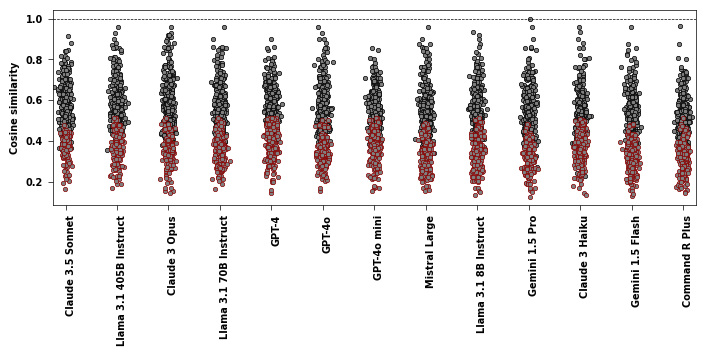

In [25]:
fig1

In [26]:
fig1.savefig('res/17_figure_s4_and_table_1/figure_s4_similarity_scores.svg', format='svg')